Cubic Spline
MSE: 0.0
R^2: 1.0

Polynomial Fit
MSE: 5.261035823858551e-26
R^2: 1.0


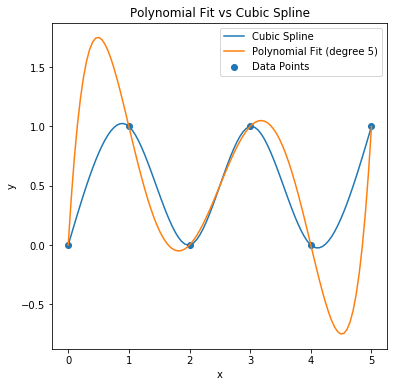

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
%matplotlib inline

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])


cs = CubicSpline(x, y, bc_type='natural')

x_interp = np.linspace(0, 5, 100)
y_interp = cs(x_interp)


degree = 5
coeffs = np.polyfit(x, y, degree)

y_poly = np.polyval(coeffs, x_interp)

y_poly_original = np.polyval(coeffs, x)

y_spline_original = cs(x)

mse_spline = np.mean((y - y_spline_original)**2)
mse_poly = np.mean((y - y_poly_original)**2)

ss_tot = np.sum((y - np.mean(y))**2)

r2_spline = 1 - (np.sum((y - y_spline_original)**2) / ss_tot)
r2_poly = 1 - (np.sum((y - y_poly_original)**2) / ss_tot)

print("Cubic Spline")
print("MSE:", mse_spline)
print("R^2:", r2_spline)

print("\nPolynomial Fit")
print("MSE:", mse_poly)
print("R^2:", r2_poly)

# ------------------------------------------------------------
# Plot Comparison
# ------------------------------------------------------------

plt.figure(figsize=(6,6))
plt.title("Polynomial Fit vs Cubic Spline")

plt.scatter(x, y, label="Data Points")
plt.plot(x_interp, y_interp, label="Cubic Spline")
plt.plot(x_interp, y_poly, label="Polynomial Fit (degree 5)")

plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.show()